# Exercise 2 — ML Key Challenges


In this exercise, you will train several models and observe three cases:

1. Underfitting — model too simple
2. Good fit — model captures the pattern
3. Overfitting — model memorizes the noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


Create synthetic nonlinear data

In [11]:
np.random.seed(42)

X = np.linspace(0, 10, 80).reshape(-1, 1)

y_true = np.sin(X).ravel()

y = y_true + np.random.normal(0, 0.25, size=y_true.shape)

Train / test split

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# For smooth plotting
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

In [13]:
models = [
    {"degree": 1, "name": "Model A"},
    {"degree": 4, "name": "Model B"},
    {"degree": 15, "name": "Model C"},
]

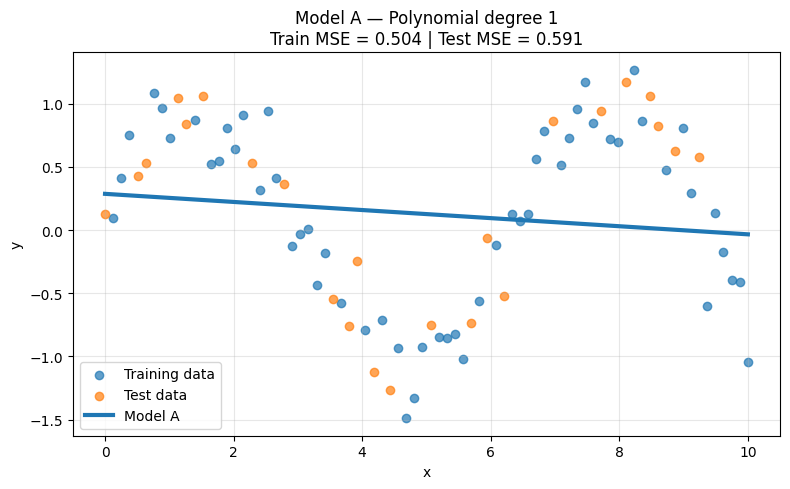

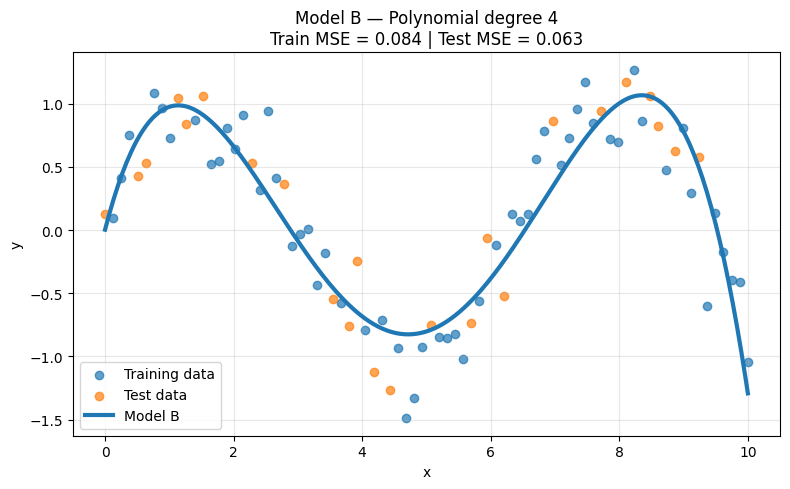

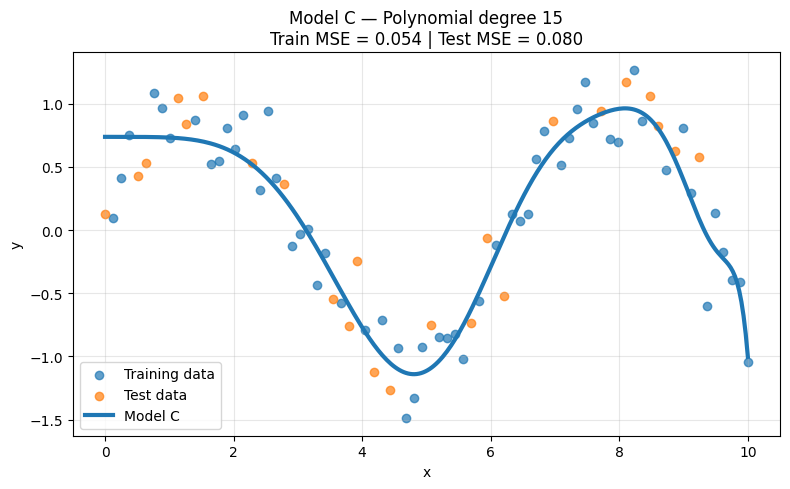

In [14]:
for item in models:
    degree = item["degree"]

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(x_plot)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    plt.figure(figsize=(8, 5))

    plt.scatter(X_train, y_train, alpha=0.7, label="Training data")
    plt.scatter(X_test, y_test, alpha=0.7, label="Test data")
    plt.plot(x_plot, y_plot, linewidth=3, label=item["name"])

    plt.title(
        f"{item['name']} — Polynomial degree {degree}\n"
        f"Train MSE = {train_mse:.3f} | Test MSE = {test_mse:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Questions

1. Which model is underfitting?
2. Which model is overfitting?
3. Which model generalizes best?
4. How do you know from the plot?
5. How do you know from the train/test MSE?

In [ ]:
# 1. Model A is underfitting

In [ ]:
# 2. Model C is overfitting

In [ ]:
# 3. Model B generalizes the best

In [ ]:
# 4. From the plot, model A has a residual line going straight through with no correlation with the data points.
#                   model C has a residual line trying to fit with the training data the best. We can notice that at the left-most and right-most side of the plot
#                   model B has a residual line that captures the patterns the best. We can even notice it ignoring the noise at the middle point of the plot

In [ ]:
# 5. From the train/test MSE, model A has the worst train/test MSE when comparing with the others.
#                             model C has the best train MSE but the test MSE is worse than the train MSE.
#                             model B has the train MSE higher than that of model C but the test MSE is the best.